# ID3 Decision Tree — PopOut AI Project

**Inteligência Artificial 2025/2026 — Trabalho Prático**

**Grupo**:
- [Duarte Meneses dos Santos Sousa Gomes, 202409386]
- [José Paulo Pacheco de Sousa, 202405046]
- [Tiago Braga da Cruz Frada de Sousa, 202405406]

**Repositório**: <https://github.com/Difl4/popout-ai>

---

This notebook evaluates the **ID3 classifier implemented from scratch** (`src/decision_tree/id3/learner.py`) on the Iris dataset.

**Key properties of our implementation:**
- Works on **categorical** features only (classic ID3)
- Continuous Iris features are discretised via quantile bins — **fit on training data only** to prevent leakage
- Evaluation uses **Repeated K-Fold cross-validation** (10 folds × 5 repetitions = 50 iterations)

**Sections:**
1. Setup and data loading
2. Information-theoretic foundations
3. Discretisation — avoiding data leakage
4. Repeated K-Fold cross-validation
5. Aggregate performance metrics
6. Feature importance
7. Tree structure (model trained on all data)
8. Interactive sample classification

In [1]:
import sys
from pathlib import Path

# Add project root so we can import from src/
sys.path.insert(0, str(Path('..').resolve()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.decision_tree.id3.learner import ID3Classifier
from src.decision_tree.discretizer import fit_quantile_bins, apply_bins

np.random.seed(42)
plt.style.use('ggplot')

print('Imports OK')

Imports OK


## 1. Data Loading

The Iris dataset has four **continuous** features and three classes.

In [2]:
df = pd.read_csv('../data/iris.csv')
if 'ID' in df.columns:
    df = df.drop('ID', axis=1)

TARGET = 'class'
NUMERIC_COLS = [c for c in df.columns if c != TARGET]

print(f'Shape: {df.shape}')
print(f'Features: {NUMERIC_COLS}')
print(f'Classes: {df[TARGET].value_counts().to_dict()}')
df.head()

Shape: (150, 5)
Features: ['sepallength', 'sepalwidth', 'petallength', 'petalwidth']
Classes: {'Iris-setosa': 50, 'Iris-versicolor': 50, 'Iris-virginica': 50}


,sepallength,sepalwidth,petallength,petalwidth,class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


## 2. Information-Theoretic Foundations

ID3 selects the feature that maximises **Information Gain** at each node.

**Shannon Entropy** measures the impurity of a set $S$:
$$H(S) = -\sum_{c \in C} p_c \log_2 p_c$$

A pure node (all samples belong to one class) has $H = 0$; a fully mixed binary node has $H = 1$.

**Information Gain** for feature $A$:
$$IG(S, A) = H(S) - \sum_{v \in \text{values}(A)} \frac{|S_v|}{|S|}\, H(S_v)$$

The algorithm always picks $A^* = \arg\max_A\; IG(S, A)$.

In [3]:
# Illustrate entropy and IG on the full (continuous) dataset before discretisation
clf_demo = ID3Classifier()

# Discretise all data for the demo (we discretise properly per-fold during CV)
bins_demo = fit_quantile_bins(df, NUMERIC_COLS, q=3)
df_disc_demo = apply_bins(df, bins_demo)

base_entropy = ID3Classifier.entropy(df_disc_demo[TARGET])
print(f'Dataset entropy: {base_entropy:.4f} bits\n')
print(f'{"Feature":<15} {"IG (bits)":>10}')
print('-' * 27)
for feat in NUMERIC_COLS:
    ig = clf_demo.information_gain(df_disc_demo, feat, TARGET)
    print(f'{feat:<15} {ig:>10.4f}')

Dataset entropy: 1.5850 bits

Feature          IG (bits)
---------------------------
sepallength         0.6470
sepalwidth          0.3484
petallength         1.3247
petalwidth          1.3694


## 3. Discretisation — No Data Leakage

Our `ID3Classifier` operates on **categorical** attributes.  
Continuous Iris features must be binned before training.

**`fit_quantile_bins(train_df, columns, q=3)`** — learns bin edges from **training data only**  
**`apply_bins(df, bins)`** — transforms any DataFrame using those frozen edges

In every cross-validation fold the bins are re-fitted exclusively on the training partition.  
The test partition is transformed using those training-derived edges — it never influences the splits.

## 4. Repeated K-Fold Cross-Validation

- **K = 10** folds, **5 repetitions** → 50 independent train/test evaluations
- Each repetition re-shuffles the dataset with a different random seed
- Discretisation bins are fit inside each fold on the training partition only

This gives a stable, low-variance estimate of generalisation accuracy.

In [4]:
def k_fold_split(data: pd.DataFrame, k: int, seed: int):
    """Return list of (train_df, test_df) pairs for k-fold CV."""
    shuffled = data.sample(frac=1, random_state=seed).reset_index(drop=True)
    n = len(shuffled)
    fold_size = n // k
    folds = []
    for i in range(k):
        start = i * fold_size
        end = start + fold_size if i < k - 1 else n
        test  = shuffled.iloc[start:end].reset_index(drop=True)
        train = pd.concat([
            shuffled.iloc[:start],
            shuffled.iloc[end:]
        ]).reset_index(drop=True)
        folds.append((train, test))
    return folds


K    = 10
REPS =  5
Q_BINS = 3   # quantile bins for discretisation

fold_scores  = []
all_y_true   = []
all_y_pred   = []

for rep in range(REPS):
    folds = k_fold_split(df, K, seed=rep * 100)
    for fold_idx, (train_df, test_df) in enumerate(folds):

        # --- fit discretiser on train partition only ---
        bins = fit_quantile_bins(train_df, NUMERIC_COLS, q=Q_BINS)
        train_disc = apply_bins(train_df, bins)
        test_disc  = apply_bins(test_df,  bins)

        # --- train ID3 on discretised training data ---
        clf = ID3Classifier(max_depth=10)
        clf.fit(train_disc, target=TARGET)

        # --- evaluate on discretised test partition ---
        y_true = test_disc[TARGET].astype(str).tolist()
        y_pred = clf.predict(test_disc.drop(columns=[TARGET])).tolist()

        acc = sum(t == p for t, p in zip(y_true, y_pred)) / len(y_true)
        fold_scores.append(acc)
        all_y_true.extend(y_true)
        all_y_pred.extend(y_pred)

print(f'Completed {len(fold_scores)} fold evaluations ({REPS} reps × {K} folds)')
print(f'Mean accuracy : {np.mean(fold_scores)*100:.2f}%')
print(f'Std  accuracy : {np.std(fold_scores)*100:.2f}%')
print(f'Min  accuracy : {np.min(fold_scores)*100:.2f}%')
print(f'Max  accuracy : {np.max(fold_scores)*100:.2f}%')

Completed 50 fold evaluations (5 reps × 10 folds)
Mean accuracy : 94.67%
Std  accuracy : 6.39%
Min  accuracy : 73.33%
Max  accuracy : 100.00%


## 5. Aggregate Performance Metrics

/tmp/ipykernel_10889/2524994132.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(rep_scores, labels=[f'Rep {r+1}' for r in range(REPS)])


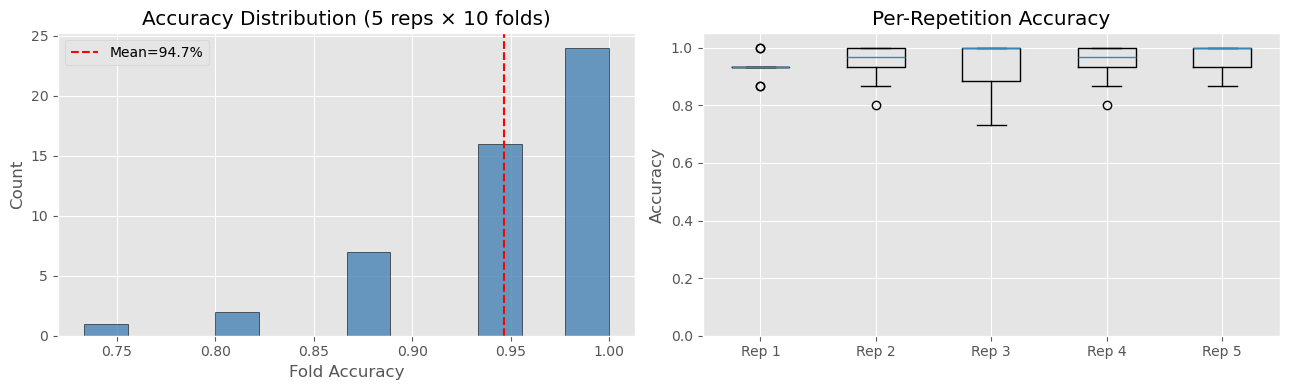

In [5]:
# Accuracy distribution across all 50 folds
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histogram
axes[0].hist(fold_scores, bins=12, edgecolor='black', color='steelblue', alpha=0.8)
axes[0].axvline(np.mean(fold_scores), color='red', linestyle='--', label=f'Mean={np.mean(fold_scores)*100:.1f}%')
axes[0].set_xlabel('Fold Accuracy')
axes[0].set_ylabel('Count')
axes[0].set_title(f'Accuracy Distribution ({REPS} reps × {K} folds)')
axes[0].legend()

# Box plot per repetition
rep_scores = [fold_scores[r*K:(r+1)*K] for r in range(REPS)]
axes[1].boxplot(rep_scores, labels=[f'Rep {r+1}' for r in range(REPS)])
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Per-Repetition Accuracy')
axes[1].set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

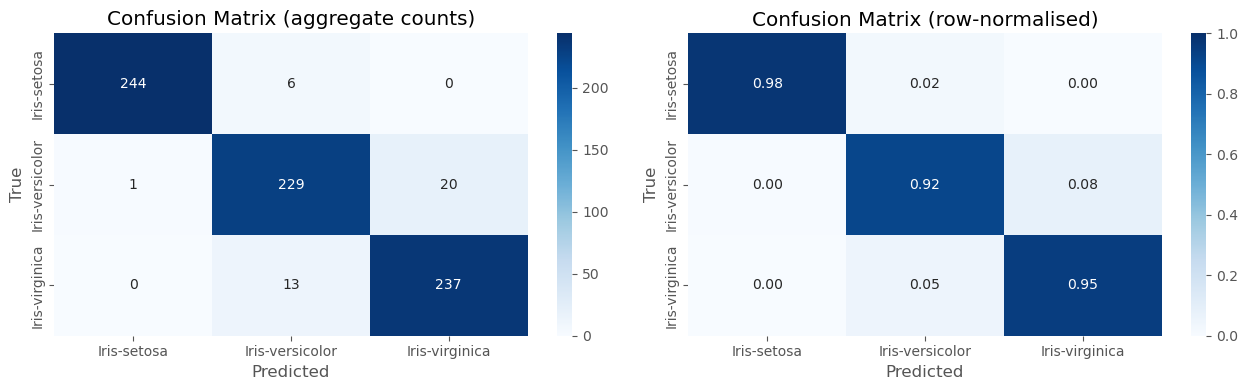

In [6]:
# Aggregate confusion matrix over all 50 × len(test_fold) predictions
classes = sorted(df[TARGET].unique())
class_to_idx = {c: i for i, c in enumerate(classes)}

cm = np.zeros((len(classes), len(classes)), dtype=int)
for true, pred in zip(all_y_true, all_y_pred):
    cm[class_to_idx[true], class_to_idx[pred]] += 1

# Normalise row-wise to show proportions
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.heatmap(cm, annot=True, fmt='d', ax=axes[0],
            xticklabels=classes, yticklabels=classes, cmap='Blues')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')
axes[0].set_title('Confusion Matrix (aggregate counts)')

sns.heatmap(cm_norm, annot=True, fmt='.2f', ax=axes[1],
            xticklabels=classes, yticklabels=classes, cmap='Blues', vmin=0, vmax=1)
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')
axes[1].set_title('Confusion Matrix (row-normalised)')

plt.tight_layout()
plt.show()

In [7]:
# Per-class Precision, Recall, F1
print(f'Overall Accuracy: {np.mean(fold_scores)*100:.2f}% ± {np.std(fold_scores)*100:.2f}%\n')
print(f'{"Class":<20} {"Precision":>10} {"Recall":>10} {"F1-Score":>10} {"Support":>9}')
print('-' * 65)

for i, c in enumerate(classes):
    tp = cm[i, i]
    fp = cm[:, i].sum() - tp
    fn = cm[i, :].sum() - tp
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    support   = cm[i, :].sum()
    print(f'{c:<20} {precision:>10.3f} {recall:>10.3f} {f1:>10.3f} {support:>9}')

print('-' * 65)
total_tp = np.trace(cm)
total    = cm.sum()
print(f'{"Accuracy":<20} {total_tp/total:>10.3f} {"":>10} {"":>10} {total:>9}')

Overall Accuracy: 94.67% ± 6.39%

Class                 Precision     Recall   F1-Score   Support
-----------------------------------------------------------------
Iris-setosa               0.996      0.976      0.986       250
Iris-versicolor           0.923      0.916      0.920       250
Iris-virginica            0.922      0.948      0.935       250
-----------------------------------------------------------------
Accuracy                  0.947                             750


## 6. Feature Importance

The tree is re-trained on the **full dataset** (discretised with bins fit on all data).  
Feature importance is computed by `ID3Classifier.get_feature_importance()` as the normalised count of decision splits that use each feature.

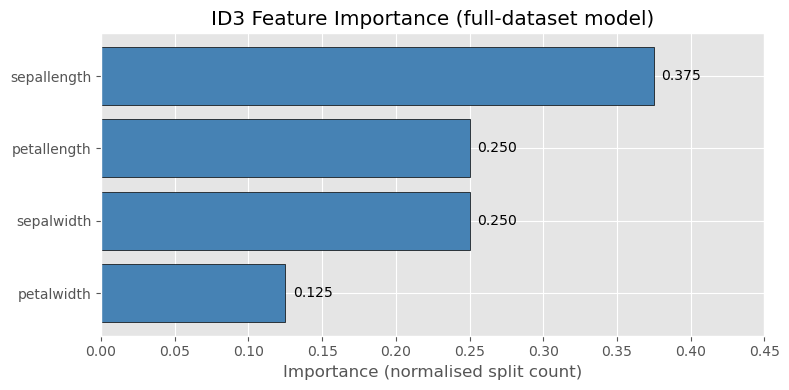

Feature importance scores:
  sepallength    : 0.3750
  petallength    : 0.2500
  sepalwidth     : 0.2500
  petalwidth     : 0.1250


In [8]:
# Final model trained on all data
bins_final  = fit_quantile_bins(df, NUMERIC_COLS, q=Q_BINS)
df_disc_all = apply_bins(df, bins_final)

final_clf = ID3Classifier(max_depth=10)
final_clf.fit(df_disc_all, target=TARGET)

importance = final_clf.get_feature_importance()

# Bar plot
feat_names  = list(importance.keys())
feat_values = list(importance.values())

plt.figure(figsize=(8, 4))
bars = plt.barh(feat_names[::-1], feat_values[::-1], color='steelblue', edgecolor='black')
plt.xlabel('Importance (normalised split count)')
plt.title('ID3 Feature Importance (full-dataset model)')
for bar, val in zip(bars, feat_values[::-1]):
    plt.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
             f'{val:.3f}', va='center', fontsize=10)
plt.xlim(0, max(feat_values) * 1.2)
plt.tight_layout()
plt.show()

print('Feature importance scores:')
for feat, val in importance.items():
    print(f'  {feat:<15}: {val:.4f}')

## 7. Tree Structure

The full-dataset model's decision tree printed with ASCII art.

In [9]:
print('Decision Tree (trained on full discretised dataset)\n')
final_clf.print_tree()

Decision Tree (trained on full discretised dataset)

[class] — split on [petalwidth]
├─ low [petallength]
│  ├─ low → Iris-versicolor
│  ├─ medium [sepallength]
│  │  ├─ low [sepalwidth]
│  │  │  ├─ low → Iris-virginica
│  │  │  ├─ medium → Iris-virginica
│  │  │  └─ very_low → Iris-virginica
│  │  ├─ medium → Iris-virginica
│  │  └─ very_low → Iris-virginica
│  └─ very_low → Iris-versicolor
├─ medium [sepalwidth]
│  ├─ low [petallength]
│  │  ├─ low [sepallength]
│  │  │  ├─ low → Iris-virginica
│  │  │  ├─ medium → Iris-virginica
│  │  │  └─ very_low → Iris-virginica
│  │  ├─ medium [sepallength]
│  │  │  ├─ low → Iris-virginica
│  │  │  ├─ medium → Iris-virginica
│  │  │  └─ very_low → Iris-virginica
│  │  └─ very_low → Iris-virginica
│  ├─ medium → Iris-virginica
│  └─ very_low → Iris-virginica
└─ very_low → Iris-setosa


## 8. Interactive Sample Classification

Change the four measurement values below and re-run the cell to classify a new iris sample.

The input is discretised using the same bins derived from the full training set before being fed to the model.

In [10]:
# ============================================================
# Change these values to test a new sample
# ============================================================
sepal_length = 6.0   # typical range: 4.3 – 7.9
sepal_width  = 3.0   # typical range: 2.0 – 4.4
petal_length = 4.8   # typical range: 1.0 – 6.9
petal_width  = 1.8   # typical range: 0.1 – 2.5
# ============================================================

sample_df   = pd.DataFrame([{
    'sepallength': sepal_length,
    'sepalwidth':  sepal_width,
    'petallength': petal_length,
    'petalwidth':  petal_width,
}])
sample_disc = apply_bins(sample_df, bins_final)
row         = sample_disc.iloc[0]

prediction  = final_clf.predict_one(row)

print('+' + '-' * 52 + '+')
print('| MANUAL SAMPLE CLASSIFICATION')
print('+' + '-' * 52 + '+')
print(f'|  Sepal length : {sepal_length} cm  →  {row["sepallength"]}')
print(f'|  Sepal width  : {sepal_width} cm  →  {row["sepalwidth"]}')
print(f'|  Petal length : {petal_length} cm  →  {row["petallength"]}')
print(f'|  Petal width  : {petal_width} cm  →  {row["petalwidth"]}')
print('|')
print(f'|  >>> ID3 PREDICTION: {prediction.upper()} <<<')
print('+' + '-' * 52 + '+')

+----------------------------------------------------+
| MANUAL SAMPLE CLASSIFICATION
+----------------------------------------------------+
|  Sepal length : 6.0 cm  →  low
|  Sepal width  : 3.0 cm  →  low
|  Petal length : 4.8 cm  →  low
|  Petal width  : 1.8 cm  →  medium
|
|  >>> ID3 PREDICTION: IRIS-VIRGINICA <<<
+----------------------------------------------------+
